In [1]:
import json
import os
import numpy as np
import cupy as cp

from model import GoePT
from dataset import Dataset


with open(os.path.join("../..", "checkpoints", 'class_rock_pop_80percent.json'), mode='r', encoding='utf-8') as in_file:
    state_dict = json.load(in_file)

model = GoePT.from_state_dict(state_dict)

rng = np.random.default_rng()

In [2]:
#only_genres = ["baroque", "rock", "classical", "pop", "renaissance"]
only_genres = ["rock", "pop", "classical"]
test_dataset = Dataset("test", only_genres=only_genres, uniform=True, data_dir="../../data", context_length=model.context_length)
test_dataset.get_slices(context_length=model.context_length, data_dir='../../data') # precompute slices, they stay cached

print("Dataset loaded.")


Dataset loaded.


In [ ]:


top1_correct = 0
samples_seen = 0

for _ in range(5):
    x, y = test_dataset.get_batch_from_slices(model.batch_size, rng=rng)
    x, y = cp.asarray(x), cp.asarray(y)
    logits, loss = model.forward(x,targets=y,train= False)

    top1_correct += (cp.argmax(logits,-1).flatten()==y).sum().item()
    samples_seen += y.size

print(f"Top1 accuracy: {top1_correct/samples_seen:.4f} ({top1_correct}/{samples_seen})")

In [ ]:
for genre in only_genres:
    top1_correct = 0
    samples_seen = 0

    for _ in range(5):
        track = test_dataset.tracks[genre][rng.integers(len(test_dataset.tracks[genre]))]

        x, y = test_dataset.get_batch_from_track(track, model.context_length, model.batch_size)
        x, y = cp.asarray(x), cp.asarray(y)
        logits, loss = model.forward(x,targets=y,train= False)

        top1_correct += (cp.argmax(logits,-1).flatten()==y).sum().item()
        samples_seen += y.size

    print(f"Top1 accuracy for {genre}: {top1_correct/samples_seen:.4f} ({top1_correct}/{samples_seen})")

In [ ]:
def accuracy_for_genre(genre):
    dataset_genre = Dataset("test", only_genres=[genre], uniform=True, data_dir="../../data", context_length=model.context_length)
    dataset_genre.get_slices(context_length=model.context_length, data_dir='../../data')

    top1_correct = {}
    for g in sorted(only_genres):
        top1_correct[g] = 0

    CNT = 30
    for _ in range(CNT):
        y = 0
        for g in sorted(only_genres):
            track = dataset_genre.tracks[genre][rng.integers(len(dataset_genre.tracks[genre]))]

            x, yx = dataset_genre.get_batch_from_track(track, model.context_length, model.batch_size)
            x, yx = cp.asarray(x), cp.asarray(yx)
            Y = cp.asarray(np.full((model.batch_size,), y))
            logits, _ = model.forward(x,targets=yx,train= False)

            top1_correct[g] += (cp.argmax(logits,-1).flatten()==Y).sum().item()

            y += 1
    
    for g in only_genres:
        top1_correct[g] /= CNT * model.batch_size
    
    return top1_correct


genres_to_analyze = ["baroque", "rock", "classical", "pop", "renaissance", "jazz", "romantic", "instrumental", 'metal', 'hits of the 1980s', 'country']
genres_to_analyze = sorted(genres_to_analyze)
acc_genre = {}
for genre in genres_to_analyze:
    acc = accuracy_for_genre(genre)
    acc_genre[genre] = acc
    print(genre)
    print(acc)


In [ ]:
import matplotlib.pyplot as plt

# Create a figure and a set of subplots
fig, axes = plt.subplots(1, 11, figsize=(50, 5), sharey=True)


#genres_to_analyze = ["classical", "pop", "rock", "baroque", "country"]
genres_to_analyze = sorted(["baroque", "rock", "classical", "pop", "renaissance"]) + sorted(["jazz", "romantic", "instrumental", 'metal', 'hits of the 1980s', 'country'])

# Plot each genre's classification distribution
for i, genre in enumerate(genres_to_analyze):
    if genre in only_genres:
        color = "#546E7A"
    else:
        color = "#1E88E5"

    data = acc_genre[genre]
    axes[i].bar(data.keys(), data.values(), width=0.7, color=color)
    axes[i].set_title(genre.title(), fontsize=14)
    axes[i].tick_params(axis='both', which='major', labelsize=14)
    if i == 0:
        axes[i].set_ylabel('Accuracy', fontsize=17)

plt.savefig("genre_accuracy.svg")
plt.tight_layout()
plt.show()

In [ ]:
min_dataset = Dataset("test", only_genres=['hip-hop-rap'], uniform=True, data_dir="../../data", context_length=model.context_length)
min_dataset.get_slices(context_length=model.context_length, data_dir='../../data')
print(len(min_dataset.tracks['hip-hop-rap']))

In [3]:
def accuracy_for_genre_per_track(genre, CNT=50):
    dataset_genre = Dataset("test", uniform=True, data_dir="../../data", context_length=model.context_length)
    dataset_genre.get_slices(context_length=model.context_length, data_dir='../../data')

    classification = {}
    for g in sorted(only_genres):
        classification[g] = 0

    for _ in range(CNT):
        class_per_batch = {}
        for g in sorted(only_genres):
            class_per_batch[g] = 0


        track = dataset_genre.tracks[genre][rng.integers(len(dataset_genre.tracks[genre]))]
        batches = dataset_genre.get_batches_from_track(track, model.context_length, model.batch_size, data_dir="../../data")

        for x in batches:
                
            x = cp.asarray(x)
            y = dataset_genre.genre_to_idx(genre)
            y = cp.asarray(np.full((model.batch_size,), y))
            logits, _ = model.forward(x,targets=y,train=False)

            max_key = ""
            max_val = -1

            for g in only_genres:
                y = dataset_genre.genre_to_idx(g)
                y = cp.asarray(np.full((model.batch_size,), y))
                val = (cp.argmax(logits,-1).flatten()==y).sum().item()

                if val > max_val:
                    max_val = val
                    max_key = g
            
            class_per_batch[max_key] += 1
            
        max_key = max(class_per_batch, key=class_per_batch.get)
        classification[max_key] += 1


    return classification

In [7]:
acc_genre = {}
genres_to_analyze = only_genres + ["baroque", "country"]
for genre in genres_to_analyze:
    print(genre)
    acc = accuracy_for_genre_per_track(genre, CNT=200)
    acc_genre[genre] = acc


rock
pop
classical
baroque
country


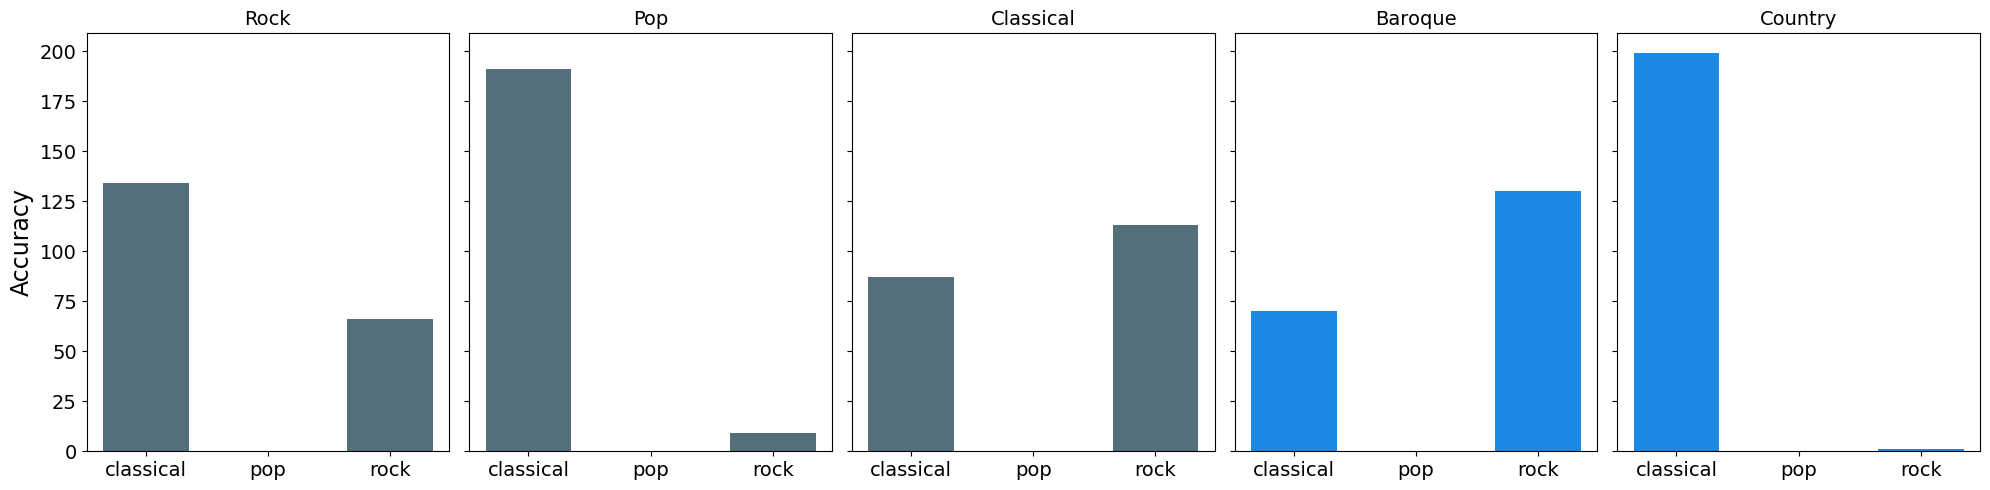

In [9]:
import matplotlib.pyplot as plt

# Create a figure and a set of subplots
fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

for i, genre in enumerate(genres_to_analyze):
    if genre in only_genres:
        color = "#546E7A"
    else:
        color = "#1E88E5"

    data = acc_genre[genre]
    axes[i].bar(data.keys(), data.values(), width=0.7, color=color)
    axes[i].set_title(genre.title(), fontsize=14)
    axes[i].tick_params(axis='both', which='major', labelsize=14)
    if i == 0:
        axes[i].set_ylabel('Accuracy', fontsize=17)

plt.savefig("genre_accuracy_per_track.svg")
plt.tight_layout()
plt.show()